In [2]:
# Cell 1: Setup
import sys
sys.path.append('../src')
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import os

In [3]:
# Cell 2: Parse MAESTRO files
from preprocessing.midi_parser import MIDIParser

maestro_root = r'D:\maestro_dataset'  # Change to your path
parser = MIDIParser(maestro_root)
all_files = parser.scan_all_midi_files()
print(f"Found {len(all_files)} .midi files")


Found 1276 .midi files


In [4]:
# Cell 3: Split by year (temporal split)
train_files, val_files, test_files = parser.split_by_year()
print(f"Train: {len(train_files)} files (2004-2011)")
print(f"Val: {len(val_files)} files (2013-2014)")
print(f"Test: {len(test_files)} files (2015-2018)")

Train: 682 files (2004-2011)
Val: 232 files (2013-2014)
Test: 362 files (2015-2018)


In [5]:
from preprocessing.piano_roll import CONFIG, midi_to_piano_roll, segment_piano_roll

print(f"Current min_velocity: {CONFIG['min_velocity']}")

Current min_velocity: 0.05


In [8]:
# Cell 4: Process all files
all_segments = []

for midi_path in tqdm(all_files, desc="Processing MAESTRO"):
    piano_roll = midi_to_piano_roll(midi_path)
    if piano_roll is not None:
        segments = segment_piano_roll(piano_roll)
        all_segments.extend(segments)

print(f"Generated {len(all_segments)} segments")
print(f"Segment shape: {all_segments[0].shape if all_segments else 'None'}")

Processing MAESTRO:   0%|          | 0/1276 [00:00<?, ?it/s]

Processing MAESTRO: 100%|██████████| 1276/1276 [04:27<00:00,  4.77it/s]

Generated 15995 segments
Segment shape: (128, 49)


SEGMENT VALIDATION REPORT
Total segments: 15995
Segment shape: (128, 49)
Data type: float32

VELOCITY STATISTICS (sample of 1000 segments):
  Mean velocity across all time-pitch cells: 0.0710
  Standard deviation: 0.0222
  Min segment mean: 0.050020
  Max segment mean: 0.2339

ACTIVITY STATISTICS:
  Mean active cells per segment (>0.01): 13.12%
  Min active cells: 7.05%
  Max active cells: 40.82%

SPARSITY CHECK:
  PASS: Mean velocity 0.0710 > 0.05 (good density)


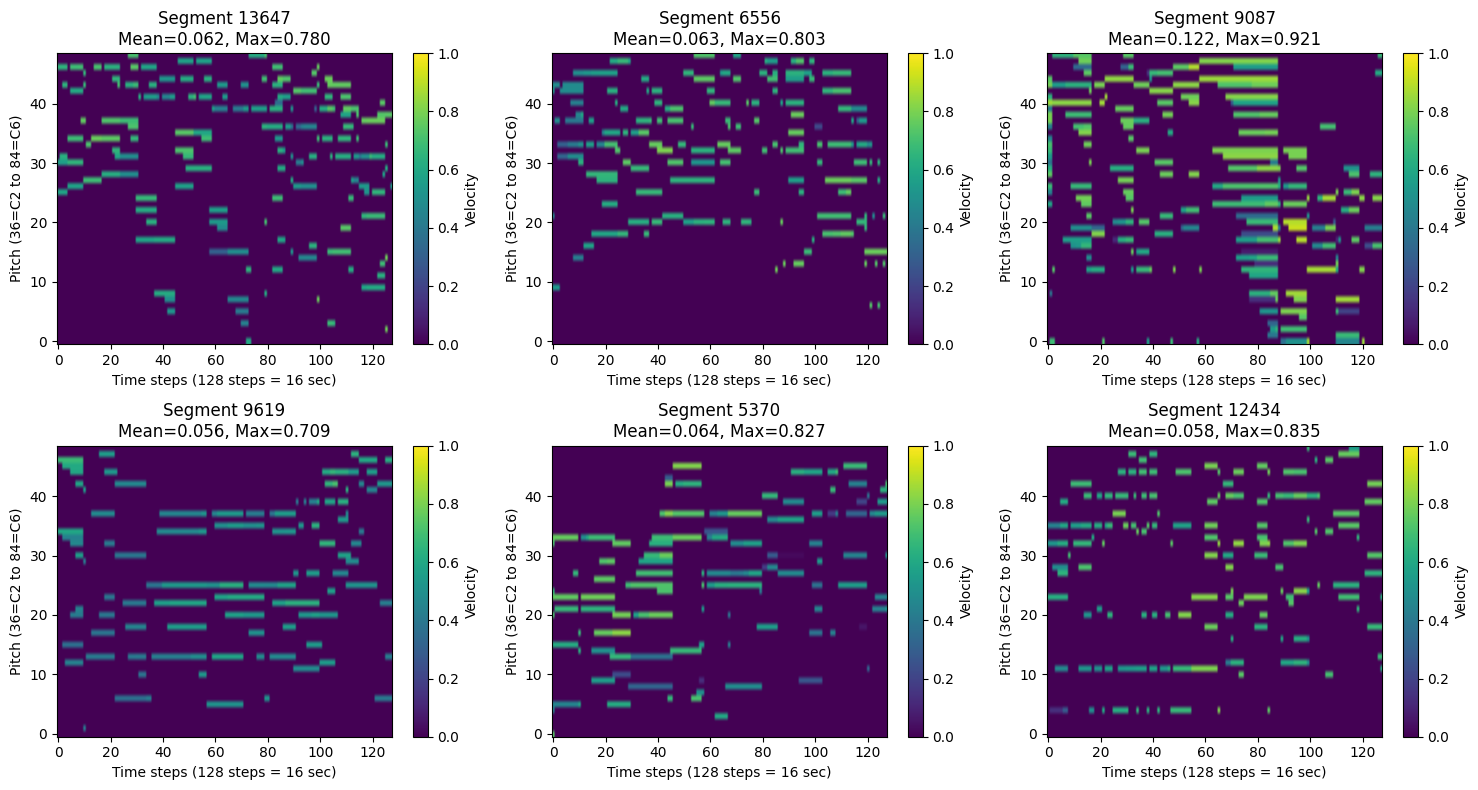

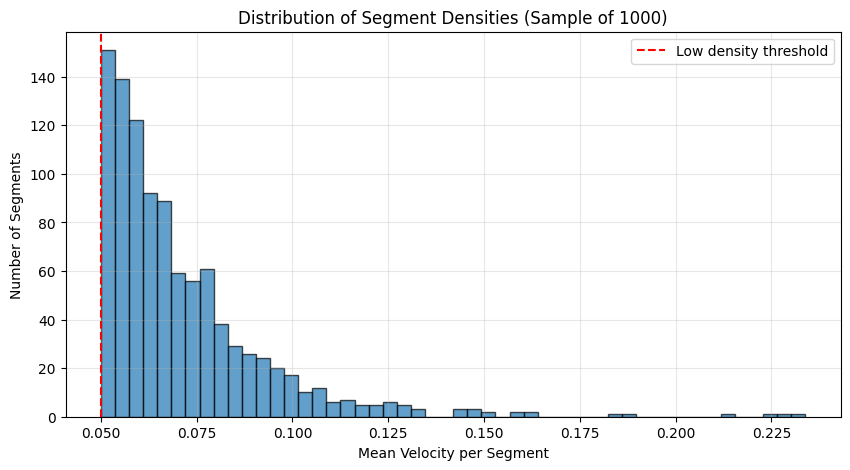

Validation complete. Proceed to save segments if statistics look good.


In [ ]:
# Cell 5: Sparsity Report and Validation

import matplotlib.pyplot as plt
import numpy as np

# Calculate statistics across all segments
all_means = []
all_maxs = []
all_nonzero_ratios = []

for segment in all_segments[:1000]:  # Sample first 1000 for speed
    all_means.append(segment.mean())
    all_maxs.append(segment.max())
    all_nonzero_ratios.append((segment > 0.01).mean())  # Velocity > 0.01 considered active

print("="*50)
print("SEGMENT VALIDATION REPORT")
print("="*50)
print(f"Total segments: {len(all_segments)}")
print(f"Segment shape: {all_segments[0].shape}")
print(f"Data type: {all_segments[0].dtype}")
print()
print("VELOCITY STATISTICS (sample of 1000 segments):")
print(f"  Mean velocity across all time-pitch cells: {np.mean(all_means):.4f}")
print(f"  Standard deviation: {np.std(all_means):.4f}")
print(f"  Min segment mean: {np.min(all_means):.6f}")
print(f"  Max segment mean: {np.max(all_means):.4f}")
print()
print("ACTIVITY STATISTICS:")
print(f"  Mean active cells per segment (>0.01): {np.mean(all_nonzero_ratios)*100:.2f}%")
print(f"  Min active cells: {np.min(all_nonzero_ratios)*100:.2f}%")
print(f"  Max active cells: {np.max(all_nonzero_ratios)*100:.2f}%")
print()
print("SPARSITY CHECK:")
if np.mean(all_means) > 0.05:
    print(f"  PASS: Mean velocity {np.mean(all_means):.4f} > 0.05 (good density)")
else:
    print(f"  WARNING: Mean velocity {np.mean(all_means):.4f} is very low")

# Visualize a few segments
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for i in range(6):
    idx = np.random.randint(0, len(all_segments))
    segment = all_segments[idx]
    im = axes[i].imshow(segment.T, aspect='auto', origin='lower', cmap='viridis', vmin=0, vmax=1)
    axes[i].set_title(f'Segment {idx}\nMean={segment.mean():.3f}, Max={segment.max():.3f}')
    axes[i].set_xlabel('Time steps (128 steps = 16 sec)')
    axes[i].set_ylabel('Pitch (36=C2 to 84=C6)')
    plt.colorbar(im, ax=axes[i], label='Velocity')

plt.tight_layout()
plt.savefig('../outputs/plots/maestro_segments_validation.png', dpi=150)
plt.show()

# Plot distribution of segment means
plt.figure(figsize=(10, 5))
plt.hist(all_means, bins=50, alpha=0.7, edgecolor='black')
plt.xlabel('Mean Velocity per Segment')
plt.ylabel('Number of Segments')
plt.title('Distribution of Segment Densities (Sample of 1000)')
plt.axvline(x=0.05, color='red', linestyle='--', label='Low density threshold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('../outputs/plots/maestro_density_distribution.png', dpi=150)
plt.show()

print("Validation complete. Proceed to save segments if statistics look good.")

In [ ]:
# Cell 6: Save segments
segments_array = np.array(all_segments, dtype=np.float32)
np.save('../data/processed/maestro_segments.npy', segments_array)
print(f"Saved to ../data/processed/maestro_segments.npy")
print(f"Shape: {segments_array.shape}, Memory: {segments_array.nbytes / 1024 / 1024:.1f} MB")

Saved to ../data/processed/maestro_segments.npy
Shape: (15995, 128, 49), Memory: 382.7 MB


In [ ]:
# Cell 7: Train/val/test split (by file, preserving temporal order)
train_segments = []
val_segments = []
test_segments = []

for f in train_files:
    pr = midi_to_piano_roll(f)
    if pr is not None:
        train_segments.extend(segment_piano_roll(pr))

for f in val_files:
    pr = midi_to_piano_roll(f)
    if pr is not None:
        val_segments.extend(segment_piano_roll(pr))

for f in test_files:
    pr = midi_to_piano_roll(f)
    if pr is not None:
        test_segments.extend(segment_piano_roll(pr))

np.save('../data/train_test_split/train.npy', np.array(train_segments))
np.save('../data/train_test_split/val.npy', np.array(val_segments))
np.save('../data/train_test_split/test.npy', np.array(test_segments))

print(f"Train: {len(train_segments)}")
print(f"Val: {len(val_segments)}")
print(f"Test: {len(test_segments)}")

Train: 8830
Val: 3204
Test: 3961


: 

In [ ]:
# Cell 8: Tokenize dataset for Task 3
from preprocessing.tokenizer import tokenize_dataset
import numpy as np

# Load piano roll segments
segments = np.load('../data/processed/lakh_segments.npy')
print(f"Loaded {len(segments)} segments of shape {segments.shape[1:]}")

# Tokenize
tokenizer, tokenized_sequences = tokenize_dataset(
    segments, 
    max_vocab_size=1000,  # Limit vocabulary size
    min_frequency=5        # Only keep tokens appearing at least 5 times
)

# Save tokenized data
import pickle
with open('../data/processed/tokenized_sequences.pkl', 'wb') as f:
    pickle.dump(tokenized_sequences, f)

# Save tokenizer
tokenizer.save('../data/processed/music_tokenizer.pkl')

print(f"\nTokenization complete")
print(f"Vocabulary size: {len(tokenizer.token_to_id)}")
print(f"Total tokenized sequences: {len(tokenized_sequences)}")
print(f"Example sequence length: {len(tokenized_sequences[0])}")

Loaded 14409 segments of shape (64, 49)
Building vocabulary from piano roll segments...
Found 16404 unique tokens
Vocabulary size: 1000 (including <PAD>, <UNK>)
Tokenizer saved to ../data/processed/music_tokenizer.pkl

Tokenization complete
Vocabulary size: 1000
Total tokenized sequences: 14409
Example sequence length: 64
